In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\kevin\.cache\kagglehub\datasets\pavansubhasht\ibm-hr-analytics-attrition-dataset\versions\1


In [2]:
import pandas as pd
import os

df = pd.read_csv(os.path.join(path, "WA_Fn-UseC_-HR-Employee-Attrition.csv"))

In [3]:
print(df.head())
print(df.shape)
print(df.info())
print(df.describe())
print(df.columns)

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [4]:
print(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [5]:
print(df.isna().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [6]:
print(df.duplicated().sum())


0


In [7]:
df_clean = df.copy()

In [8]:
print(df_clean["DailyRate"].describe())

count    1470.000000
mean      802.485714
std       403.509100
min       102.000000
25%       465.000000
50%       802.000000
75%      1157.000000
max      1499.000000
Name: DailyRate, dtype: float64


In [9]:
df_clean.to_csv("cleaned_data.csv", index=False)

## 4주차: 탐색적 데이터 분석 (EDA)

In [10]:
df_clean = pd.read_csv("cleaned_data.csv")

count    1470.000000
mean       11.279592
std         7.780782
min         0.000000
25%         6.000000
50%        10.000000
75%        15.000000
max        40.000000
Name: TotalWorkingYears, dtype: float64


<Axes: ylabel='Frequency'>

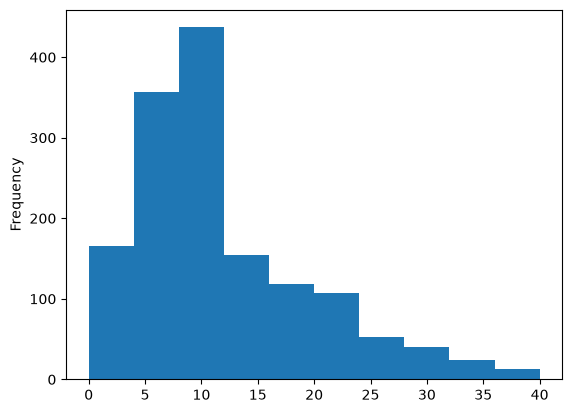

In [11]:
print(df_clean["TotalWorkingYears"].describe())
df_clean["TotalWorkingYears"].plot(kind="hist")

In [12]:
print(df_clean["Attrition"].value_counts())
print(df_clean["Attrition"].value_counts(normalize=True))

Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64


<Axes: title={'center': 'TotalWorkingYears'}, xlabel='Attrition'>

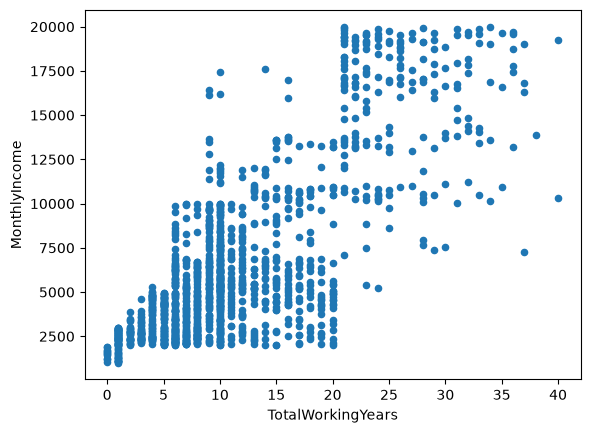

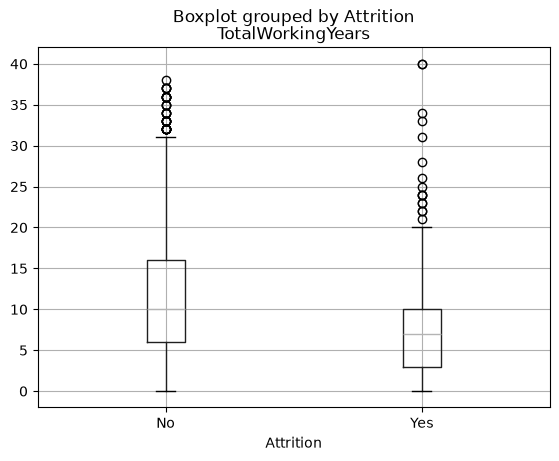

In [13]:
df_clean.plot(x="TotalWorkingYears", y="MonthlyIncome", kind="scatter")
df_clean.boxplot(column="TotalWorkingYears", by="Attrition")

<Axes: xlabel='OverTime'>

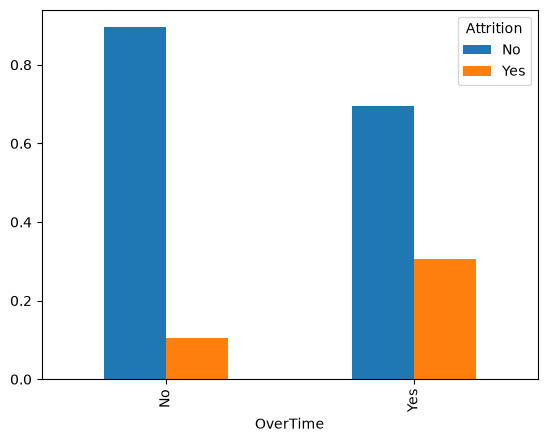

In [14]:
pd.crosstab(df_clean["OverTime"], df_clean["Attrition"], normalize="index").plot(kind="bar")

## 5주차: 파생변수와 그룹별 요약

In [15]:
df_clean = pd.read_csv("cleaned_data.csv")

### 1. 파생변수 만들기


In [16]:
df_clean["IncomePerYear"] = df_clean["MonthlyIncome"] * 12
df_clean["TenureRatio"] = df_clean["YearsAtCompany"] / df_clean["TotalWorkingYears"]

print(df_clean[["MonthlyIncome", "IncomePerYear"]].head())
print(df_clean["TenureRatio"].describe())
print(df_clean["TenureRatio"].isna().sum())

   MonthlyIncome  IncomePerYear
0           5993          71916
1           5130          61560
2           2090          25080
3           2909          34908
4           3468          41616
count    1459.000000
mean        0.683186
std         0.323978
min         0.000000
25%         0.419872
50%         0.800000
75%         1.000000
max         1.000000
Name: TenureRatio, dtype: float64
11


```md
파생변수 1: IncomePerYear (MonthlyIncome * 12)
의미: 월 소득을 연 소득으로 환산한 값. MonthlyIncome만 보는 것보다 연 단위 비교가 익숙해서 만듦

파생변수 2: TenureRatio (YearsAtCompany / TotalWorkingYears)
의미: 전체 경력 중 현재 회사에서 보낸 기간의 비율. 1에 가까울수록 첫 직장부터 계속 다닌 사람, 낮을수록 이직 경험이 많거나 최근에 옮긴 사람
TotalWorkingYears가 0인 행 11개는 나눗셈 결과가 NaN으로 나옴 (분모가 0이라 계산 불가, 신입 사원으로 추정)
```


### 2. 그룹별 요약표 만들기

In [17]:
summary = df_clean.groupby("Department")["MonthlyIncome"].mean().sort_values(ascending=False)
print(summary)

Department
Sales                     6959.172646
Human Resources           6654.507937
Research & Development    6281.252862
Name: MonthlyIncome, dtype: float64


```md
Sales 부서가 평균 소득이 가장 높고, Research & Development가 가장 낮음. 다만 세 부서 간 차이가 크지는 않음 (약 700 정도)
```


### 3. 피벗 테이블 만들기

In [18]:
pivot = pd.pivot_table(
    df_clean,
    values="MonthlyIncome",
    index="Department",
    columns="Attrition",
    aggfunc="mean"
)
print(pivot)

Attrition                        No          Yes
Department                                      
Human Resources         7345.980392  3715.750000
Research & Development  6630.326087  4108.075188
Sales                   7232.240113  5908.456522


```md
부서 구분 없이 이직(Attrition=Yes)한 사람의 평균 소득이 이직하지 않은 사람보다 뚜렷하게 낮음
특히 Human Resources는 그 격차가 가장 커서(7346 vs 3716), 저소득 인력의 이직 위험이 큰 부서로 보임
```


### 4. 핵심 결과 정리

```md
가장 중요한 요약표: Department x Attrition 피벗 테이블
요약표에서 발견한 점: 부서와 무관하게 이직자의 평균 소득이 재직자보다 낮고, Human Resources에서 그 격차가 가장 크게 나타남
분석 질문에 대한 현재 답변: 소득 수준이 낮을수록 이직 가능성이 높다는 경향이 부서 전반에서 확인되며, 특히 Human Resources에서 저소득-이직 간 연관이 두드러짐
```


### 선택 과제: 비율 지표 만들기

In [19]:
ratio = df_clean["MonthlyIncome"] / df_clean["MonthlyIncome"].sum()
print(ratio.head())

0    0.000627
1    0.000537
2    0.000219
3    0.000304
4    0.000363
Name: MonthlyIncome, dtype: float64


```md
전체 소득 총합 대비 각 직원 소득이 차지하는 비중을 계산함. 개별 값은 매우 작지만(0.03~0.06% 수준), 특정 직원이 전체에서 차지하는 비중이 지나치게 크지는 않은지 확인하는 용도로 사용 가능
```


## 6주차: 시각화

In [20]:
import matplotlib.pyplot as plt

df_clean = pd.read_csv("cleaned_data.csv")

### 1. 그래프 1: OverTime 여부별 이직률 (막대그래프)

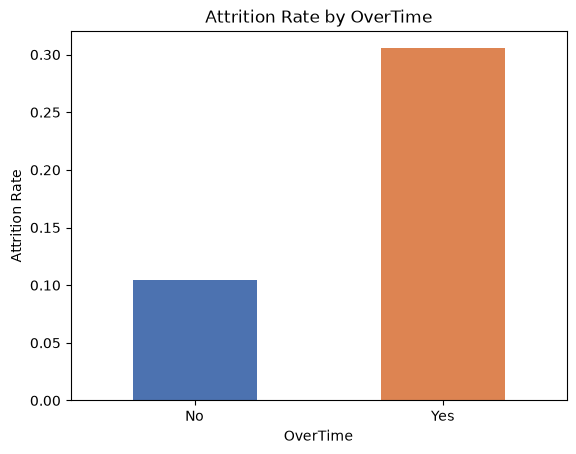

In [21]:
attrition_rate = pd.crosstab(df_clean["OverTime"], df_clean["Attrition"], normalize="index")["Yes"]
attrition_rate.plot(kind="bar", color=["#4C72B0", "#DD8452"])
plt.title("Attrition Rate by OverTime")
plt.xlabel("OverTime")
plt.ylabel("Attrition Rate")
plt.xticks(rotation=0)
plt.show()

### 2. 그래프 2: 이직 여부별 월 소득 분포 (히스토그램)

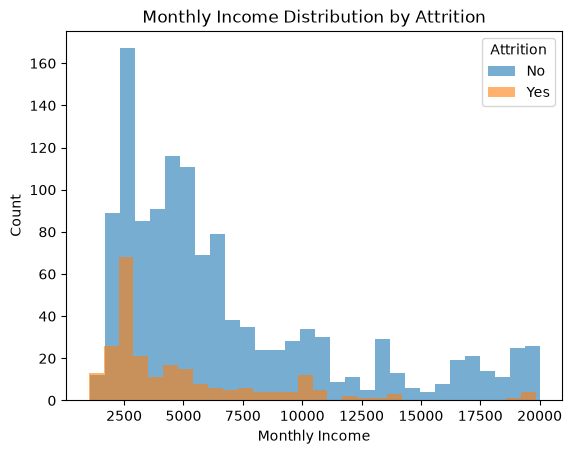

In [22]:
df_clean[df_clean["Attrition"] == "No"]["MonthlyIncome"].plot(kind="hist", bins=30, alpha=0.6, label="No")
df_clean[df_clean["Attrition"] == "Yes"]["MonthlyIncome"].plot(kind="hist", bins=30, alpha=0.6, label="Yes")
plt.title("Monthly Income Distribution by Attrition")
plt.xlabel("Monthly Income")
plt.ylabel("Count")
plt.legend(title="Attrition")
plt.show()

### 3. 그래프 3: 나이와 월 소득의 관계 (산점도)

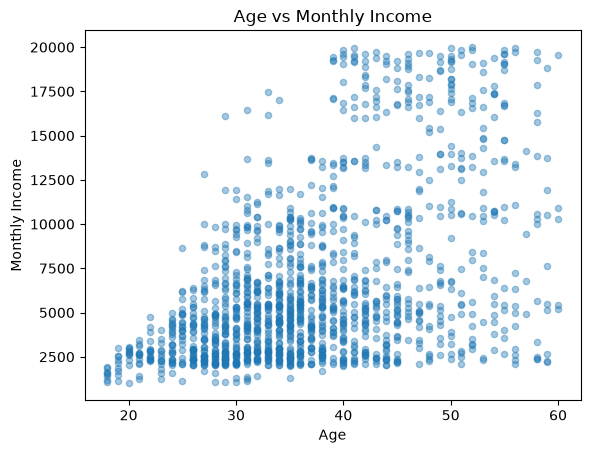

In [23]:
df_clean.plot(x="Age", y="MonthlyIncome", kind="scatter", alpha=0.4)
plt.title("Age vs Monthly Income")
plt.xlabel("Age")
plt.ylabel("Monthly Income")
plt.show()

```md
그래프 1:
보여주는 내용: OverTime(초과근무) 여부에 따른 이직률 비교
해석: 초과근무를 하는 그룹의 이직률이 30.5%로, 하지 않는 그룹(10.4%)보다 3배 가까이 높음. 초과근무가 이직과 밀접하게 연관된 변수로 보임

그래프 2:
보여주는 내용: 이직 여부(Attrition)별 월 소득(MonthlyIncome) 분포 비교
해석: 이직자(Yes)는 저소득 구간에 몰려있고, 재직자(No)는 전체 구간에 고르게 퍼져 있음. 평균도 이직자가 4787, 재직자가 6833으로 차이가 남. 5주차에서 본 부서별 소득-이직 관계와 같은 방향의 결과

그래프 3:
보여주는 내용: 나이(Age)와 월 소득(MonthlyIncome) 간의 산점도
해석: 나이가 많을수록 소득이 높아지는 양의 상관관계가 뚜렷하게 보임 (상관계수 약 0.5). 다만 같은 나이대에서도 소득 편차가 커서 나이만으로 소득을 설명하기는 부족함
```


```md
주장 후보 1: 초과근무 여부가 이직과 강하게 연관되어 있다
근거: OverTime=Yes 그룹의 이직률(30.5%)이 OverTime=No 그룹(10.4%)보다 약 3배 높음

주장 후보 2: 소득 수준이 낮을수록 이직 가능성이 높다
근거: 이직자의 평균 월 소득(4787)이 재직자(6833)보다 낮고, 히스토그램에서도 이직자가 저소득 구간에 집중됨. 5주차 부서별 피벗 테이블에서도 동일한 패턴 확인

주장 후보 3: 나이와 소득은 어느 정도 비례하지만 변수 하나로는 설명력이 부족하다
근거: Age-MonthlyIncome 상관계수가 0.5 수준으로 중간 정도이며, 같은 나이대 안에서도 소득 편차가 커서 직급, 부서 등 다른 변수를 함께 봐야 함
```


### 선택 과제: 그래프 종류 비교

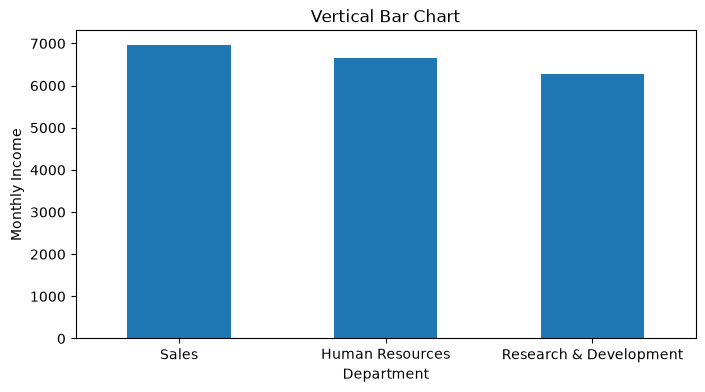

In [24]:
summary = df_clean.groupby("Department")["MonthlyIncome"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
summary.plot(kind="bar")
plt.title("Vertical Bar Chart")
plt.xlabel("Department")
plt.ylabel("Monthly Income")
plt.xticks(rotation=0)
plt.show()

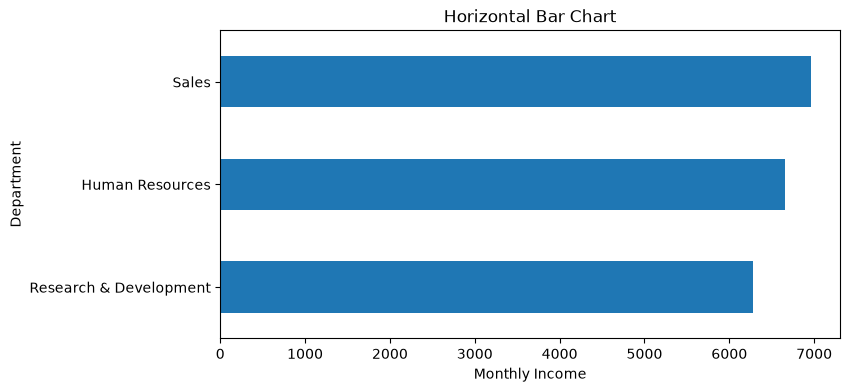

In [25]:
plt.figure(figsize=(8, 4))
summary.sort_values().plot(kind="barh")
plt.title("Horizontal Bar Chart")
plt.xlabel("Monthly Income")
plt.ylabel("Department")
plt.show()

```md
비교한 그래프 1: 부서별 평균 월 소득 세로 막대그래프
비교한 그래프 2: 부서별 평균 월 소득 가로 막대그래프
더 적절하다고 판단한 그래프: 가로 막대그래프
그 이유: 부서명(Human Resources, Research & Development)처럼 글자 수가 긴 범주는 세로 막대그래프에서 x축 라벨이 겹치거나 회전해야 해서 읽기 불편함. 가로 막대그래프는 범주명을 y축에 그대로 눕혀서 보여줄 수 있어 가독성이 더 좋고, sort_values()로 정렬했을 때 순위 비교도 더 직관적임
```
